In [47]:
import pandas as pd

df = pd.read_csv('../data/two_family/two_bedroom_home_values_zhvi.csv')
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,83344.619196,83497.156791,83684.847454,84091.160679,84557.592462,...,277241.936397,277526.843786,277198.318728,276742.253826,276169.920203,275633.122039,275112.204608,274665.813407,274477.206797,274460.149670
1,394913,1,"New York, NY",msa,NY,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.543280,501943.159082,502520.987387,503787.986518,505959.517755
2,753899,2,"Los Angeles, CA",msa,CA,169268.869371,169770.742761,170557.108176,172122.066322,173918.512499,...,739340.366867,737367.317096,732430.376873,727847.217695,723154.901146,719715.670089,717796.297400,717200.432449,717758.646596,719204.031024
3,394463,3,"Chicago, IL",msa,IL,101240.341888,101307.680756,101494.824515,101957.624150,102486.461458,...,252355.909350,253601.969084,254472.719490,255259.830574,255858.780978,256472.099230,257137.517327,257805.365792,258636.005319,259640.316581
4,394514,4,"Dallas, TX",msa,TX,69947.134256,69950.433460,69921.040192,69949.877922,70042.336016,...,231877.347334,231554.401161,230705.281883,229449.430718,227668.139913,225851.865008,224088.182881,222762.971545,221753.254434,220990.167480


In [48]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist()[:10], "...")  # Show first 10 columns
print(f"\nTotal columns: {len(df.columns)}")


Dataset Shape: (851, 315)

Column Names:
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31'] ...

Total columns: 315


In [49]:
# Check for New York in the dataset
print("Unique Region Names (first 20):")
print(df['RegionName'].unique()[:20])
print("\nChecking for New York:")
ny_regions = df[df['RegionName'].str.contains('New York', case=False, na=False)]
print(f"Found {len(ny_regions)} regions with 'New York' in name:")
print(ny_regions[['RegionName', 'StateName']].to_string())


Unique Region Names (first 20):
['United States' 'New York, NY' 'Los Angeles, CA' 'Chicago, IL'
 'Dallas, TX' 'Houston, TX' 'Washington, DC' 'Philadelphia, PA'
 'Miami, FL' 'Atlanta, GA' 'Boston, MA' 'Phoenix, AZ' 'San Francisco, CA'
 'Riverside, CA' 'Detroit, MI' 'Seattle, WA' 'Minneapolis, MN'
 'San Diego, CA' 'Tampa, FL' 'Denver, CO']

Checking for New York:
Found 1 regions with 'New York' in name:
     RegionName StateName
1  New York, NY        NY


In [50]:
import matplotlib.pyplot as plt

# Filter for New York and save to house_prices_df
house_prices_df = df[df["RegionName"] == "New York, NY"].copy()
print(f"Selected region: {house_prices_df[['RegionName', 'StateName']].values}")

# Drop non-date columns
price_data = house_prices_df.loc[:, "2000-01-31":]

# Convert to long format
price_long = price_data.melt(var_name="Date", value_name="MedianPrice")

# Convert Date column to datetime
price_long["Date"] = pd.to_datetime(price_long["Date"])

# Sort by date
price_long = price_long.sort_values("Date")

# Basic stats on the price data
print(f"\nPrice data statistics:")
print(price_long['MedianPrice'].describe())
print(f"\nDate range: {price_long['Date'].min()} to {price_long['Date'].max()}")
print(f"Total data points: {len(price_long)}")
print(f"Missing values: {price_long['MedianPrice'].isna().sum()}")

Selected region: [['New York, NY' 'NY']]

Price data statistics:
count       310.000000
mean     307278.498047
std       83733.545629
min      149779.400352
25%      258038.444729
50%      292721.634988
75%      336809.448671
max      505959.517755
Name: MedianPrice, dtype: float64

Date range: 2000-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 310
Missing values: 0


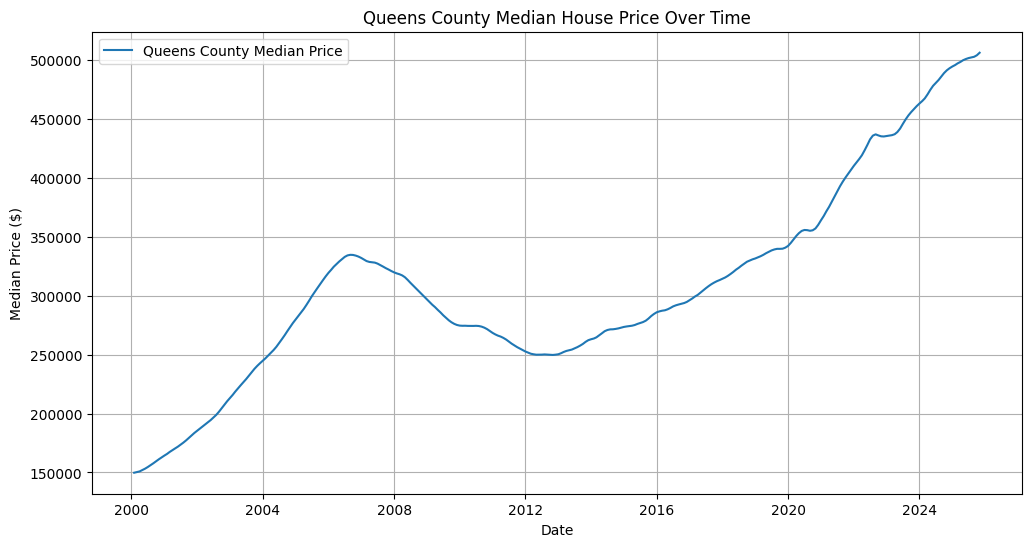

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(
    price_long["Date"], price_long["MedianPrice"], label="Queens County Median Price"
)
plt.title("Queens County Median House Price Over Time")
plt.xlabel("Date")
plt.ylabel("Median Price ($)")
plt.legend()
plt.grid(True)
plt.show()


In [52]:
house_prices_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
1,394913,1,"New York, NY",msa,NY,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755


In [53]:
house_prices_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 1 to 1
Columns: 315 entries, RegionID to 2025-10-31
dtypes: float64(310), int64(2), object(3)
memory usage: 2.5+ KB


In [54]:
house_prices_df.describe()

,RegionID,SizeRank,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,2000-06-30,2000-07-31,2000-08-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
count,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000
mean,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
25%,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
50%,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
75%,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755
max,394913.0,1.0,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,154592.99749,156139.678503,157776.935544,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755


In [55]:
# Check for duplicates
print("Duplicate rows:", house_prices_df.duplicated().sum())
print("Duplicate RegionIDs:", house_prices_df.duplicated(subset=['RegionID']).sum())

Duplicate rows: 0
Duplicate RegionIDs: 0


In [56]:
# Check for missing values
print("Total missing values:", house_prices_df.isna().sum().sum())
print("\nMissing values by column:")
print(house_prices_df.isna().sum()[house_prices_df.isna().sum() > 0])

Total missing values: 0

Missing values by column:
Series([], dtype: int64)


In [57]:
# Fill missing value using forward fill
house_prices_df = house_prices_df.fillna(method='ffill', axis=1)

In [58]:
# Check for missing values
print("Total missing values:", house_prices_df.isna().sum().sum())


Total missing values: 0


In [59]:
# Check what columns are in price_long
print("Columns:", price_long.columns.tolist())
print("\nFirst few rows:")
print(price_long.head())

Columns: ['Date', 'MedianPrice']

First few rows:
        Date    MedianPrice
0 2000-01-31  149779.400352
1 2000-02-29  150341.824571
2 2000-03-31  150875.340267
3 2000-04-30  151997.364168
4 2000-05-31  153210.460044


In [60]:
price_long.tail()

,Date,MedianPrice
305,2025-06-30,501426.543280
306,2025-07-31,501943.159082
307,2025-08-31,502520.987387
308,2025-09-30,503787.986518
309,2025-10-31,505959.517755


In [61]:
# Prepare for Prophet (needs 'ds' and 'y' columns)
price_long_prophet = price_long.reset_index().rename(columns={'Date': 'ds', 'MedianPrice': 'y'})

In [62]:
# ============================================
# RENTAL PRICES PREPROCESSING
# ============================================

# Read rental prices data
df_rental = pd.read_csv('../data/two_family/multifamily_rental_values_zori.csv')
df_rental.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,1158.783988,1163.832511,1171.228028,1175.383296,1179.722988,...,1759.350958,1762.586059,1764.857840,1766.494654,1767.438485,1769.352650,1771.503856,1774.625304,1777.314551,1779.303397
1,394913,1,"New York, NY",msa,NY,2264.111314,2278.386759,2291.166855,2302.839542,2309.751952,...,3245.116452,3258.020542,3269.225487,3278.078413,3285.458244,3298.403296,3318.815111,3340.302367,3357.934444,3372.411185
2,753899,2,"Los Angeles, CA",msa,CA,1671.176815,1680.585170,1693.221301,1708.879031,1722.529108,...,2651.097018,2656.867508,2659.684129,2660.694913,2660.979740,2663.835613,2665.229675,2669.891583,2672.608704,2675.925646
3,394463,3,"Chicago, IL",msa,IL,1312.935431,1313.914270,1319.733261,1322.067956,1326.647735,...,1889.175377,1898.419009,1907.877827,1917.834781,1927.050832,1936.667240,1946.329096,1955.600635,1964.607449,1971.554976
4,394514,4,"Dallas, TX",msa,TX,1040.141326,1036.535751,1039.603121,1052.215637,1058.206610,...,1522.378780,1523.219947,1522.109029,1522.868214,1520.149379,1518.771051,1516.142182,1515.500922,1515.062818,1512.591988


In [63]:
# Basic information
print("Dataset Shape:", df_rental.shape)
print("\nColumn Names (first 10):")
print(df_rental.columns.tolist()[:10])
print(f"\nTotal columns: {len(df_rental.columns)}")

Dataset Shape: (584, 135)

Column Names (first 10):
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30', '2015-05-31']

Total columns: 135


In [64]:
# Data types and info
df_rental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Columns: 135 entries, RegionID to 2025-10-31
dtypes: float64(130), int64(2), object(3)
memory usage: 616.1+ KB


In [65]:
# Check for New York
print("Checking for New York:")
ny_rental = df_rental[df_rental['RegionName'].str.contains('New York', case=False, na=False)]
print(f"Found {len(ny_rental)} regions with 'New York' in name:")
print(ny_rental[['RegionName', 'StateName']].to_string())

Checking for New York:
Found 1 regions with 'New York' in name:
     RegionName StateName
1  New York, NY        NY


In [66]:
# Filter for New York and save to rental_prices_df
rental_prices_df = df_rental[df_rental['RegionName'] == 'New York, NY'].copy()
# Or try: df_rental[df_rental['RegionName'].str.contains('New York', case=False, na=False)].copy()
print(f"Selected region: {rental_prices_df[['RegionName', 'StateName']].values}")
print(f"Shape: {rental_prices_df.shape}")

Selected region: [['New York, NY' 'NY']]
Shape: (1, 135)


In [67]:
# Check for duplicates
print("Duplicate rows:", rental_prices_df.duplicated().sum())
print("Duplicate RegionIDs:", rental_prices_df.duplicated(subset=['RegionID']).sum())

Duplicate rows: 0
Duplicate RegionIDs: 0


In [68]:
# Check for missing values
print("Total missing values:", rental_prices_df.isna().sum().sum())


Total missing values: 7


In [69]:
# Drop non-date columns
rental_price_data = rental_prices_df.loc[:, "2015-01-31":]  # Adjust start date as needed

# Convert to long format
rental_long = rental_price_data.melt(var_name="Date", value_name="RentalPrice")

# Convert Date column to datetime
rental_long["Date"] = pd.to_datetime(rental_long["Date"])

# Sort by date
rental_long = rental_long.sort_values("Date")

# Set Date as index
rental_long = rental_long.set_index("Date")

# Basic stats on the rental data
print(f"\nRental data statistics:")
print(rental_long['RentalPrice'].describe())
print(f"\nDate range: {rental_long.index.min()} to {rental_long.index.max()}")
print(f"Total data points: {len(rental_long)}")
print(f"Missing values: {rental_long['RentalPrice'].isna().sum()}")


Rental data statistics:
count     123.000000
mean     2679.910984
std       348.842085
min      2264.111314
25%      2397.551613
50%      2512.327970
75%      3026.686119
max      3372.411185
Name: RentalPrice, dtype: float64

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 130
Missing values: 7


In [70]:
# Verify ready for time series
print("Date range:", rental_long.index.min(), "to", rental_long.index.max())
print("Total points:", len(rental_long))
print("Date is datetime:", pd.api.types.is_datetime64_any_dtype(rental_long.index))
print("No missing:", rental_long['RentalPrice'].isna().sum() == 0)
print("No duplicates:", rental_long.index.duplicated().sum() == 0)
print("Is sorted:", rental_long.index.is_monotonic_increasing)

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total points: 130
Date is datetime: True
No missing: False
No duplicates: True
Is sorted: True


In [71]:
# ============================================
# MORTGAGE RATES PREPROCESSING
# ============================================

from fredapi import Fred
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Get FRED API key from environment
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

# Pull 30-Year Fixed Rate Mortgage, monthly data
mortgage = fred.get_series(
    "MORTGAGE30US", start_date="2015-01-01", end_date="2025-12-01"
)

# Convert to DataFrame
mortgage_df = mortgage.to_frame(name="mortgage_rate")
mortgage_df.index.name = "date"
mortgage_df.reset_index(inplace=True)

# Keep only data from 2015 onwards
mortgage_df = mortgage_df[mortgage_df["date"] >= "2015-01-01"]

# Convert date to datetime
mortgage_df["date"] = pd.to_datetime(mortgage_df["date"])

# Convert to monthly (take end of month value)
mortgage_df["month"] = mortgage_df["date"].dt.to_period("M")
mortgage_df_monthly = mortgage_df.groupby("month")["mortgage_rate"].last().reset_index()
mortgage_df_monthly["Date"] = mortgage_df_monthly["month"].dt.to_timestamp()
mortgage_df_monthly = mortgage_df_monthly.drop(columns=["month"])

# Set Date as index
mortgage_df_monthly = mortgage_df_monthly.set_index("Date")

print("Mortgage data statistics:")
print(mortgage_df_monthly['mortgage_rate'].describe())
print(f"\nDate range: {mortgage_df_monthly.index.min()} to {mortgage_df_monthly.index.max()}")
print(f"Total data points: {len(mortgage_df_monthly)}")


Mortgage data statistics:
count    132.000000
mean       4.694697
std        1.453832
min        2.670000
25%        3.640000
50%        4.045000
75%        6.327500
max        7.790000
Name: mortgage_rate, dtype: float64

Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00
Total data points: 132


In [72]:
# ============================================
# MERGE ALL DATA
# ============================================

# Reset indices to merge on Date
price_long_reset = price_long.reset_index()
rental_long_reset = rental_long.reset_index()
mortgage_reset = mortgage_df_monthly.reset_index()

# Convert all dates to end of month for alignment
price_long_reset['Date'] = pd.to_datetime(price_long_reset['Date'])
rental_long_reset['Date'] = pd.to_datetime(rental_long_reset['Date'])
mortgage_reset['Date'] = pd.to_datetime(mortgage_reset['Date'])

# Merge house prices and rental prices first (both monthly)
merged_df = pd.merge(price_long_reset, rental_long_reset, on='Date', how='outer')

# Merge with mortgage rates
merged_df = pd.merge(merged_df, mortgage_reset, on='Date', how='outer')

# Sort by date
merged_df = merged_df.sort_values('Date')

# Filter to common date range (2015 onwards where all data exists)
merged_df = merged_df[merged_df['Date'] >= '2015-01-01']

# Set Date as index
merged_df = merged_df.set_index('Date')

print("Merged dataset shape:", merged_df.shape)
print("\nFirst few rows:")
print(merged_df.head())
print("\nLast few rows:")
print(merged_df.tail())
print("\nMissing values:")
print(merged_df.isna().sum())


Merged dataset shape: (262, 4)

First few rows:
            index    MedianPrice  RentalPrice  mortgage_rate
Date                                                        
2015-01-01    NaN            NaN          NaN           3.66
2015-01-31  180.0  273827.089475  2264.111314            NaN
2015-02-01    NaN            NaN          NaN           3.80
2015-02-28  181.0  274085.123904  2278.386759            NaN
2015-03-01    NaN            NaN          NaN           3.69

Last few rows:
            index    MedianPrice  RentalPrice  mortgage_rate
Date                                                        
2025-09-30  308.0  503787.986518  3357.934444            NaN
2025-10-01    NaN            NaN          NaN           6.17
2025-10-31  309.0  505959.517755  3372.411185            NaN
2025-11-01    NaN            NaN          NaN           6.23
2025-12-01    NaN            NaN          NaN           6.22

Missing values:
index            132
MedianPrice      132
RentalPrice      139
mo

In [73]:
# ============================================
# TIME SERIES FORECASTING WITH PROPHET
# ============================================

from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')


In [74]:
# Prepare house prices for Prophet (needs 'ds' and 'y' columns)
house_prices_prophet = price_long.reset_index().rename(columns={'Date': 'ds', 'MedianPrice': 'y'})

# Create and fit Prophet model for house prices
model_house = Prophet()
model_house.fit(house_prices_prophet)

# Create future dataframe (5 years = 60 months, 10 years = 120 months)
future_house = model_house.make_future_dataframe(periods=120, freq='M')  # 10 years forecast

# Make forecast
forecast_house = model_house.predict(future_house)

print("House Prices Forecast:")
print(f"Forecast period: {forecast_house['ds'].min()} to {forecast_house['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_house[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


01:23:59 - cmdstanpy - INFO - Chain [1] start processing
01:23:59 - cmdstanpy - INFO - Chain [1] done processing


House Prices Forecast:
Forecast period: 2000-01-31 00:00:00 to 2035-10-31 00:00:00

Last 5 forecasted values:
            ds           yhat     yhat_lower     yhat_upper
425 2035-06-30  804324.880981  651445.686567  947349.539531
426 2035-07-31  806873.247141  650086.288863  953370.172088
427 2035-08-31  809123.094764  650769.748142  955979.311537
428 2035-09-30  811378.738834  653618.452985  959878.183827
429 2035-10-31  813779.840859  651645.041089  964731.508514


In [75]:
# Prepare rental prices for Prophet
rental_prices_prophet = rental_long.reset_index().rename(columns={'Date': 'ds', 'RentalPrice': 'y'})

# Create and fit Prophet model for rental prices
model_rental = Prophet()
model_rental.fit(rental_prices_prophet)

# Create future dataframe (10 years forecast)
future_rental = model_rental.make_future_dataframe(periods=120, freq='M')

# Make forecast
forecast_rental = model_rental.predict(future_rental)

print("Rental Prices Forecast:")
print(f"Forecast period: {forecast_rental['ds'].min()} to {forecast_rental['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_rental[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


01:24:00 - cmdstanpy - INFO - Chain [1] start processing
01:24:00 - cmdstanpy - INFO - Chain [1] done processing


Rental Prices Forecast:
Forecast period: 2015-01-31 00:00:00 to 2035-10-31 00:00:00

Last 5 forecasted values:
            ds         yhat   yhat_lower   yhat_upper
245 2035-06-30  4616.409096  1215.971890  8000.834995
246 2035-07-31  4626.117835  1209.159790  8033.943246
247 2035-08-31  4636.632509  1174.985802  8068.931766
248 2035-09-30  4647.647156  1141.228200  8147.523525
249 2035-10-31  4661.391013  1125.649260  8177.861627


In [76]:
# Optional: Forecast mortgage rates
mortgage_prophet = mortgage_df_monthly.reset_index().rename(columns={'Date': 'ds', 'mortgage_rate': 'y'})

# Create and fit Prophet model for mortgage rates
model_mortgage = Prophet()
model_mortgage.fit(mortgage_prophet)

# Create future dataframe (10 years forecast)
future_mortgage = model_mortgage.make_future_dataframe(periods=120, freq='M')

# Make forecast
forecast_mortgage = model_mortgage.predict(future_mortgage)

print("Mortgage Rates Forecast:")
print(f"Forecast period: {forecast_mortgage['ds'].min()} to {forecast_mortgage['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_mortgage[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


01:24:00 - cmdstanpy - INFO - Chain [1] start processing
01:24:00 - cmdstanpy - INFO - Chain [1] done processing


Mortgage Rates Forecast:
Forecast period: 2015-01-01 00:00:00 to 2035-11-30 00:00:00

Last 5 forecasted values:
            ds       yhat  yhat_lower  yhat_upper
247 2035-07-31  14.268819   12.631362   15.876764
248 2035-08-31  14.468950   12.792125   16.237983
249 2035-09-30  14.672264   13.028350   16.485180
250 2035-10-31  14.581658   12.810530   16.350793
251 2035-11-30  14.550788   12.848222   16.207549


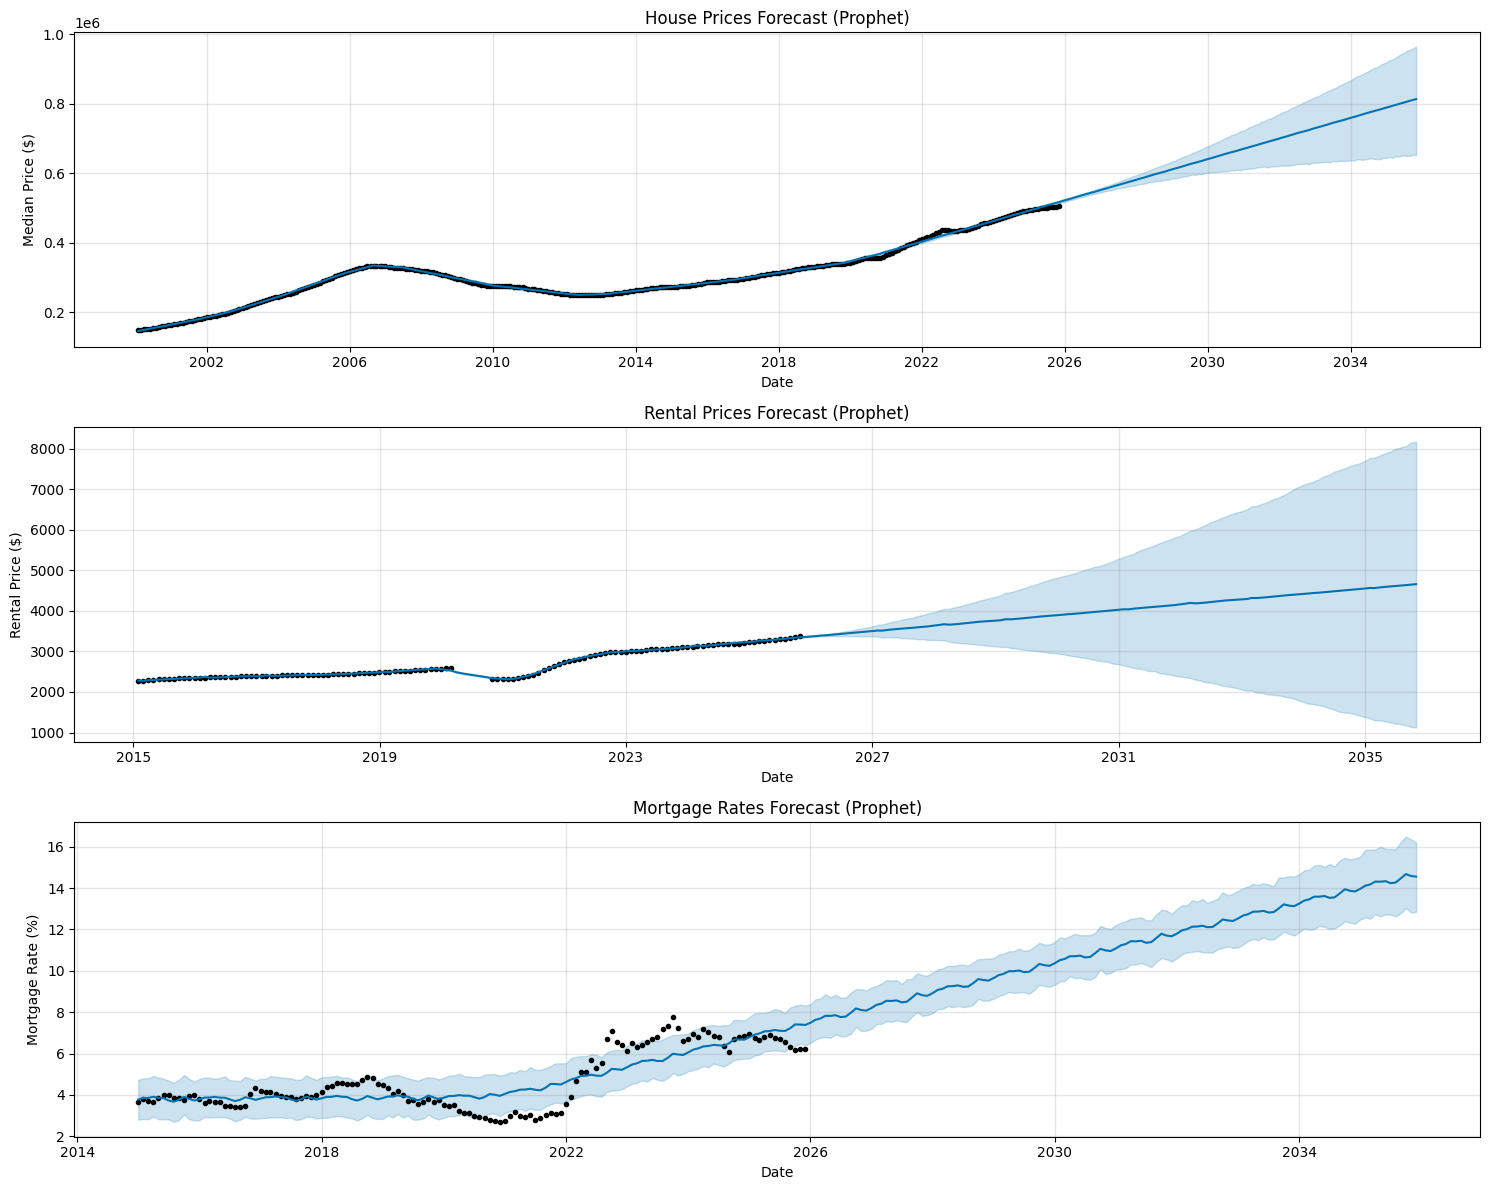

In [77]:
# Visualize forecasts
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# House prices forecast
model_house.plot(forecast_house, ax=axes[0])
axes[0].set_title('House Prices Forecast (Prophet)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Median Price ($)')

# Rental prices forecast
model_rental.plot(forecast_rental, ax=axes[1])
axes[1].set_title('Rental Prices Forecast (Prophet)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rental Price ($)')

# Mortgage rates forecast
model_mortgage.plot(forecast_mortgage, ax=axes[2])
axes[2].set_title('Mortgage Rates Forecast (Prophet)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Mortgage Rate (%)')

plt.tight_layout()
plt.show()


In [78]:
# Extract forecasted values for future dates (beyond historical data)
# Get the last date from historical data
last_historical_date_house = house_prices_prophet['ds'].max()
last_historical_date_rental = rental_prices_prophet['ds'].max()
last_historical_date_mortgage = mortgage_prophet['ds'].max()

# Filter forecasts to only future dates
forecast_house_future = forecast_house[forecast_house['ds'] > last_historical_date_house].copy()
forecast_rental_future = forecast_rental[forecast_rental['ds'] > last_historical_date_rental].copy()
forecast_mortgage_future = forecast_mortgage[forecast_mortgage['ds'] > last_historical_date_mortgage].copy()

print("Future Forecasts (beyond historical data):")
print(f"\nHouse Prices - {len(forecast_house_future)} future months")
print(f"Rental Prices - {len(forecast_rental_future)} future months")
print(f"Mortgage Rates - {len(forecast_mortgage_future)} future months")


Future Forecasts (beyond historical data):

House Prices - 120 future months
Rental Prices - 120 future months
Mortgage Rates - 120 future months


In [79]:
# ============================================
# ARIMA/SARIMA TIME SERIES FORECASTING
# ============================================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
import numpy as np

print("ARIMA/SARIMA libraries imported successfully!")


ARIMA/SARIMA libraries imported successfully!


In [80]:
# ============================================
# PREPARE DATA FOR ARIMA
# ============================================

# Ensure all data has Date as index for time series analysis
# price_long currently has Date as a column, need to set it as index
price_long_ts = price_long.copy()
if 'Date' in price_long_ts.columns:
    price_long_ts = price_long_ts.set_index('Date')

# rental_long already has Date as index
rental_long_ts = rental_long.copy()

# mortgage_df_monthly already has Date as index
mortgage_long_ts = mortgage_df_monthly.copy()

# Remove any missing values
price_long_ts = price_long_ts.dropna()
rental_long_ts = rental_long_ts.dropna()
mortgage_long_ts = mortgage_long_ts.dropna()

# Extract time series (single column)
house_prices_ts = price_long_ts['MedianPrice']
rental_prices_ts = rental_long_ts['RentalPrice']
mortgage_rates_ts = mortgage_long_ts['mortgage_rate']

print("Data prepared for ARIMA:")
print(f"\nHouse Prices: {len(house_prices_ts)} observations")
print(f"  Date range: {house_prices_ts.index.min()} to {house_prices_ts.index.max()}")
print(f"\nRental Prices: {len(rental_prices_ts)} observations")
print(f"  Date range: {rental_prices_ts.index.min()} to {rental_prices_ts.index.max()}")
print(f"\nMortgage Rates: {len(mortgage_rates_ts)} observations")
print(f"  Date range: {mortgage_rates_ts.index.min()} to {mortgage_rates_ts.index.max()}")


Data prepared for ARIMA:

House Prices: 310 observations
  Date range: 2000-01-31 00:00:00 to 2025-10-31 00:00:00

Rental Prices: 123 observations
  Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00

Mortgage Rates: 132 observations
  Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00


In [81]:
# ============================================
# ARIMA FORECASTING: HOUSE PRICES
# ============================================

print("=" * 60)
print("HOUSE PRICES - ARIMA/SARIMA MODEL")
print("=" * 60)

# Use auto_arima to find optimal parameters
# Seasonal period = 12 for monthly data
print("\nSearching for optimal ARIMA parameters...")
auto_model_house = auto_arima(
    house_prices_ts,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=12,  # Monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"\nOptimal model: {auto_model_house.order} x {auto_model_house.seasonal_order}")
print(f"AIC: {auto_model_house.aic():.2f}")

# Fit the model
arima_model_house = auto_model_house.fit(house_prices_ts)

# Generate 120-month forecast
forecast_periods = 120
forecast_arima_house = arima_model_house.predict(n_periods=forecast_periods, return_conf_int=True)

# Create forecast dataframe
last_date = house_prices_ts.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_periods, freq='M')

forecast_arima_house_df = pd.DataFrame({
    'Date': forecast_dates,
    'forecast': forecast_arima_house[0],
    'lower': forecast_arima_house[1][:, 0],
    'upper': forecast_arima_house[1][:, 1]
}).set_index('Date')

print(f"\nForecast generated for {forecast_periods} months")
print(f"Forecast date range: {forecast_dates[0]} to {forecast_dates[-1]}")
print(f"\nLast 5 forecasted values:")
print(forecast_arima_house_df.tail())

# Model diagnostics
print(f"\nModel Summary:")
print(arima_model_house.summary())


HOUSE PRICES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=4580.419, Time=0.03 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=4575.439, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=4564.035, Time=0.08 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=4563.919, Time=0.10 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=4562.104, Time=0.03 sec
 ARIMA(0,2,1)(1,0,0)[12]             : AIC=4563.918, Time=0.09 sec
 ARIMA(0,2,1)(1,0,1)[12]             : AIC=4566.051, Time=0.15 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=4564.081, Time=0.09 sec
 ARIMA(0,2,2)(0,0,0)[12]             : AIC=4564.057, Time=0.05 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=4562.223, Time=0.03 sec
 ARIMA(1,2,2)(0,0,0)[12]             : AIC=4559.041, Time=0.09 sec
 ARIMA(1,2,2)(1,0,0)[12]             : AIC=4560.614, Time=0.24 sec
 ARIMA(1,2,2)(0,0,1)[12]             : AIC=4567.513, Time=0.39 sec
 ARIMA(1,

In [82]:
# ============================================
# ARIMA FORECASTING: RENTAL PRICES
# ============================================

print("=" * 60)
print("RENTAL PRICES - ARIMA/SARIMA MODEL")
print("=" * 60)

# Use auto_arima to find optimal parameters
print("\nSearching for optimal ARIMA parameters...")
auto_model_rental = auto_arima(
    rental_prices_ts,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=12,  # Monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"\nOptimal model: {auto_model_rental.order} x {auto_model_rental.seasonal_order}")
print(f"AIC: {auto_model_rental.aic():.2f}")

# Fit the model
arima_model_rental = auto_model_rental.fit(rental_prices_ts)

# Generate 120-month forecast
forecast_arima_rental = arima_model_rental.predict(n_periods=forecast_periods, return_conf_int=True)

# Create forecast dataframe
last_date_rental = rental_prices_ts.index[-1]
forecast_dates_rental = pd.date_range(start=last_date_rental + pd.DateOffset(months=1), periods=forecast_periods, freq='M')

forecast_arima_rental_df = pd.DataFrame({
    'Date': forecast_dates_rental,
    'forecast': forecast_arima_rental[0],
    'lower': forecast_arima_rental[1][:, 0],
    'upper': forecast_arima_rental[1][:, 1]
}).set_index('Date')

print(f"\nForecast generated for {forecast_periods} months")
print(f"Forecast date range: {forecast_dates_rental[0]} to {forecast_dates_rental[-1]}")
print(f"\nLast 5 forecasted values:")
print(forecast_arima_rental_df.tail())

# Model diagnostics
print(f"\nModel Summary:")
print(arima_model_rental.summary())


RENTAL PRICES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1162.434, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1159.563, Time=0.00 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1154.337, Time=0.09 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1156.229, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1170.132, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1152.712, Time=0.02 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1154.338, Time=0.07 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1156.337, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1152.123, Time=0.03 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1153.858, Time=0.12 sec
 ARIMA(2,1,0)(0,0,1)[12] intercept   : AIC=1153.860, Time=0.11 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=1155.862, Time=0.13 sec
 ARIMA(3,1,0)(0,0,0)[12] intercept   : AIC=1153.183, Time=0.04 sec
 ARIMA(2

In [83]:
# ============================================
# ARIMA FORECASTING: MORTGAGE RATES
# ============================================

print("=" * 60)
print("MORTGAGE RATES - ARIMA/SARIMA MODEL")
print("=" * 60)

# Use auto_arima to find optimal parameters
print("\nSearching for optimal ARIMA parameters...")
auto_model_mortgage = auto_arima(
    mortgage_rates_ts,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=12,  # Monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"\nOptimal model: {auto_model_mortgage.order} x {auto_model_mortgage.seasonal_order}")
print(f"AIC: {auto_model_mortgage.aic():.2f}")

# Fit the model
arima_model_mortgage = auto_model_mortgage.fit(mortgage_rates_ts)

# Generate 120-month forecast
forecast_arima_mortgage = arima_model_mortgage.predict(n_periods=forecast_periods, return_conf_int=True)

# Create forecast dataframe
last_date_mortgage = mortgage_rates_ts.index[-1]
forecast_dates_mortgage = pd.date_range(start=last_date_mortgage + pd.DateOffset(months=1), periods=forecast_periods, freq='M')

forecast_arima_mortgage_df = pd.DataFrame({
    'Date': forecast_dates_mortgage,
    'forecast': forecast_arima_mortgage[0],
    'lower': forecast_arima_mortgage[1][:, 0],
    'upper': forecast_arima_mortgage[1][:, 1]
}).set_index('Date')

print(f"\nForecast generated for {forecast_periods} months")
print(f"Forecast date range: {forecast_dates_mortgage[0]} to {forecast_dates_mortgage[-1]}")
print(f"\nLast 5 forecasted values:")
print(forecast_arima_mortgage_df.tail())

# Model diagnostics
print(f"\nModel Summary:")
print(arima_model_mortgage.summary())


MORTGAGE RATES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=0.448, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4.091, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-2.091, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-4.238, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2.942, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=0.245, Time=0.02 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-2.478, Time=0.15 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=-2.698, Time=0.42 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=-3.037, Time=0.06 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=-1.255, Time=0.04 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=-5.051, Time=0.13 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=0.414, Time=0.03 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AI

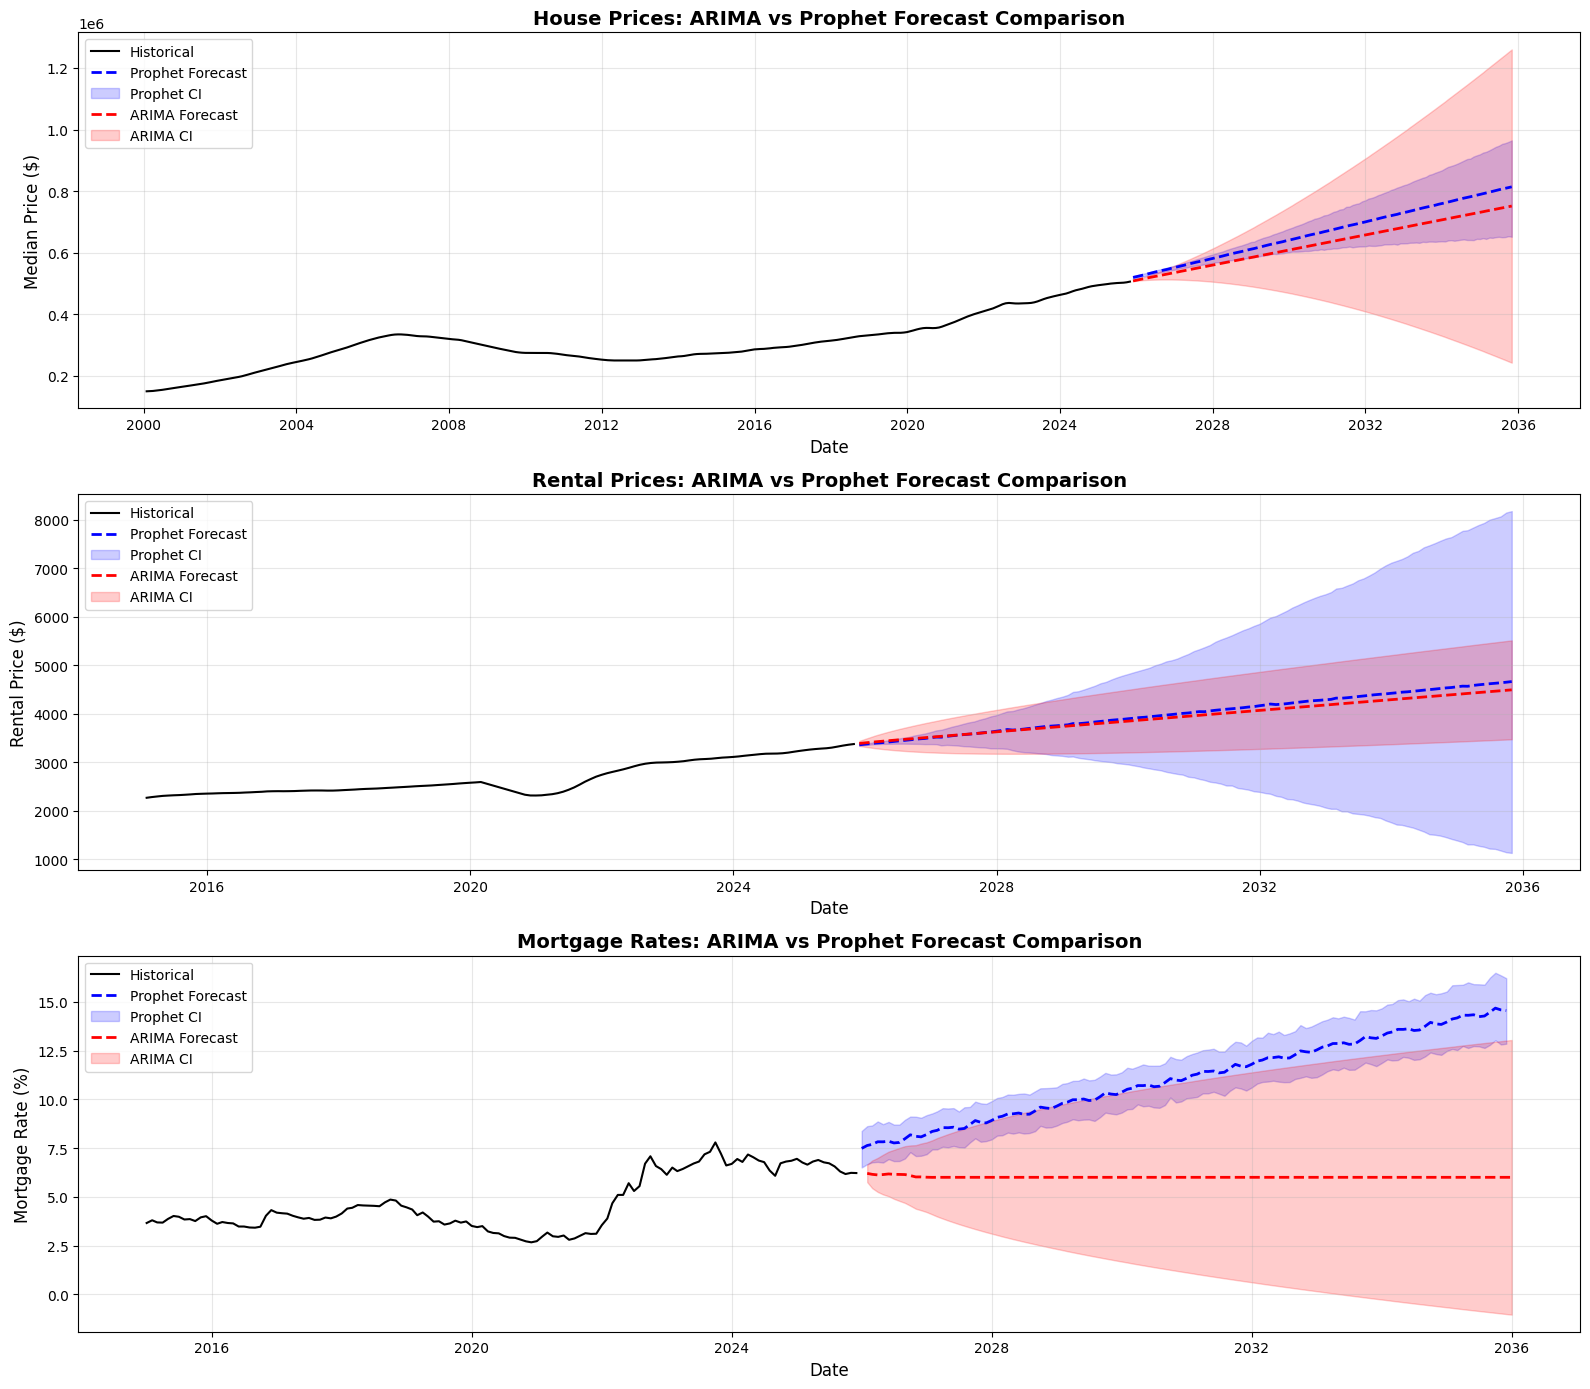

In [84]:
# ============================================
# VISUALIZATION: ARIMA vs PROPHET COMPARISON
# ============================================

# Prepare Prophet forecasts for comparison (extract future forecasts only)
prophet_house_future = forecast_house_future.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']]
prophet_rental_future = forecast_rental_future.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']]
prophet_mortgage_future = forecast_mortgage_future.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']]

# Create comparison plots
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ===== HOUSE PRICES =====
ax = axes[0]
# Historical data
ax.plot(house_prices_ts.index, house_prices_ts.values, 'k-', label='Historical', linewidth=1.5)
# Prophet forecast
ax.plot(prophet_house_future.index, prophet_house_future['yhat'], 'b--', label='Prophet Forecast', linewidth=2)
ax.fill_between(prophet_house_future.index, prophet_house_future['yhat_lower'], 
                prophet_house_future['yhat_upper'], alpha=0.2, color='blue', label='Prophet CI')
# ARIMA forecast
ax.plot(forecast_arima_house_df.index, forecast_arima_house_df['forecast'], 'r--', label='ARIMA Forecast', linewidth=2)
ax.fill_between(forecast_arima_house_df.index, forecast_arima_house_df['lower'], 
                forecast_arima_house_df['upper'], alpha=0.2, color='red', label='ARIMA CI')
ax.set_title('House Prices: ARIMA vs Prophet Forecast Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Median Price ($)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# ===== RENTAL PRICES =====
ax = axes[1]
# Historical data
ax.plot(rental_prices_ts.index, rental_prices_ts.values, 'k-', label='Historical', linewidth=1.5)
# Prophet forecast
ax.plot(prophet_rental_future.index, prophet_rental_future['yhat'], 'b--', label='Prophet Forecast', linewidth=2)
ax.fill_between(prophet_rental_future.index, prophet_rental_future['yhat_lower'], 
                prophet_rental_future['yhat_upper'], alpha=0.2, color='blue', label='Prophet CI')
# ARIMA forecast
ax.plot(forecast_arima_rental_df.index, forecast_arima_rental_df['forecast'], 'r--', label='ARIMA Forecast', linewidth=2)
ax.fill_between(forecast_arima_rental_df.index, forecast_arima_rental_df['lower'], 
                forecast_arima_rental_df['upper'], alpha=0.2, color='red', label='ARIMA CI')
ax.set_title('Rental Prices: ARIMA vs Prophet Forecast Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Rental Price ($)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# ===== MORTGAGE RATES =====
ax = axes[2]
# Historical data
ax.plot(mortgage_rates_ts.index, mortgage_rates_ts.values, 'k-', label='Historical', linewidth=1.5)
# Prophet forecast
ax.plot(prophet_mortgage_future.index, prophet_mortgage_future['yhat'], 'b--', label='Prophet Forecast', linewidth=2)
ax.fill_between(prophet_mortgage_future.index, prophet_mortgage_future['yhat_lower'], 
                prophet_mortgage_future['yhat_upper'], alpha=0.2, color='blue', label='Prophet CI')
# ARIMA forecast
ax.plot(forecast_arima_mortgage_df.index, forecast_arima_mortgage_df['forecast'], 'r--', label='ARIMA Forecast', linewidth=2)
ax.fill_between(forecast_arima_mortgage_df.index, forecast_arima_mortgage_df['lower'], 
                forecast_arima_mortgage_df['upper'], alpha=0.2, color='red', label='ARIMA CI')
ax.set_title('Mortgage Rates: ARIMA vs Prophet Forecast Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mortgage Rate (%)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


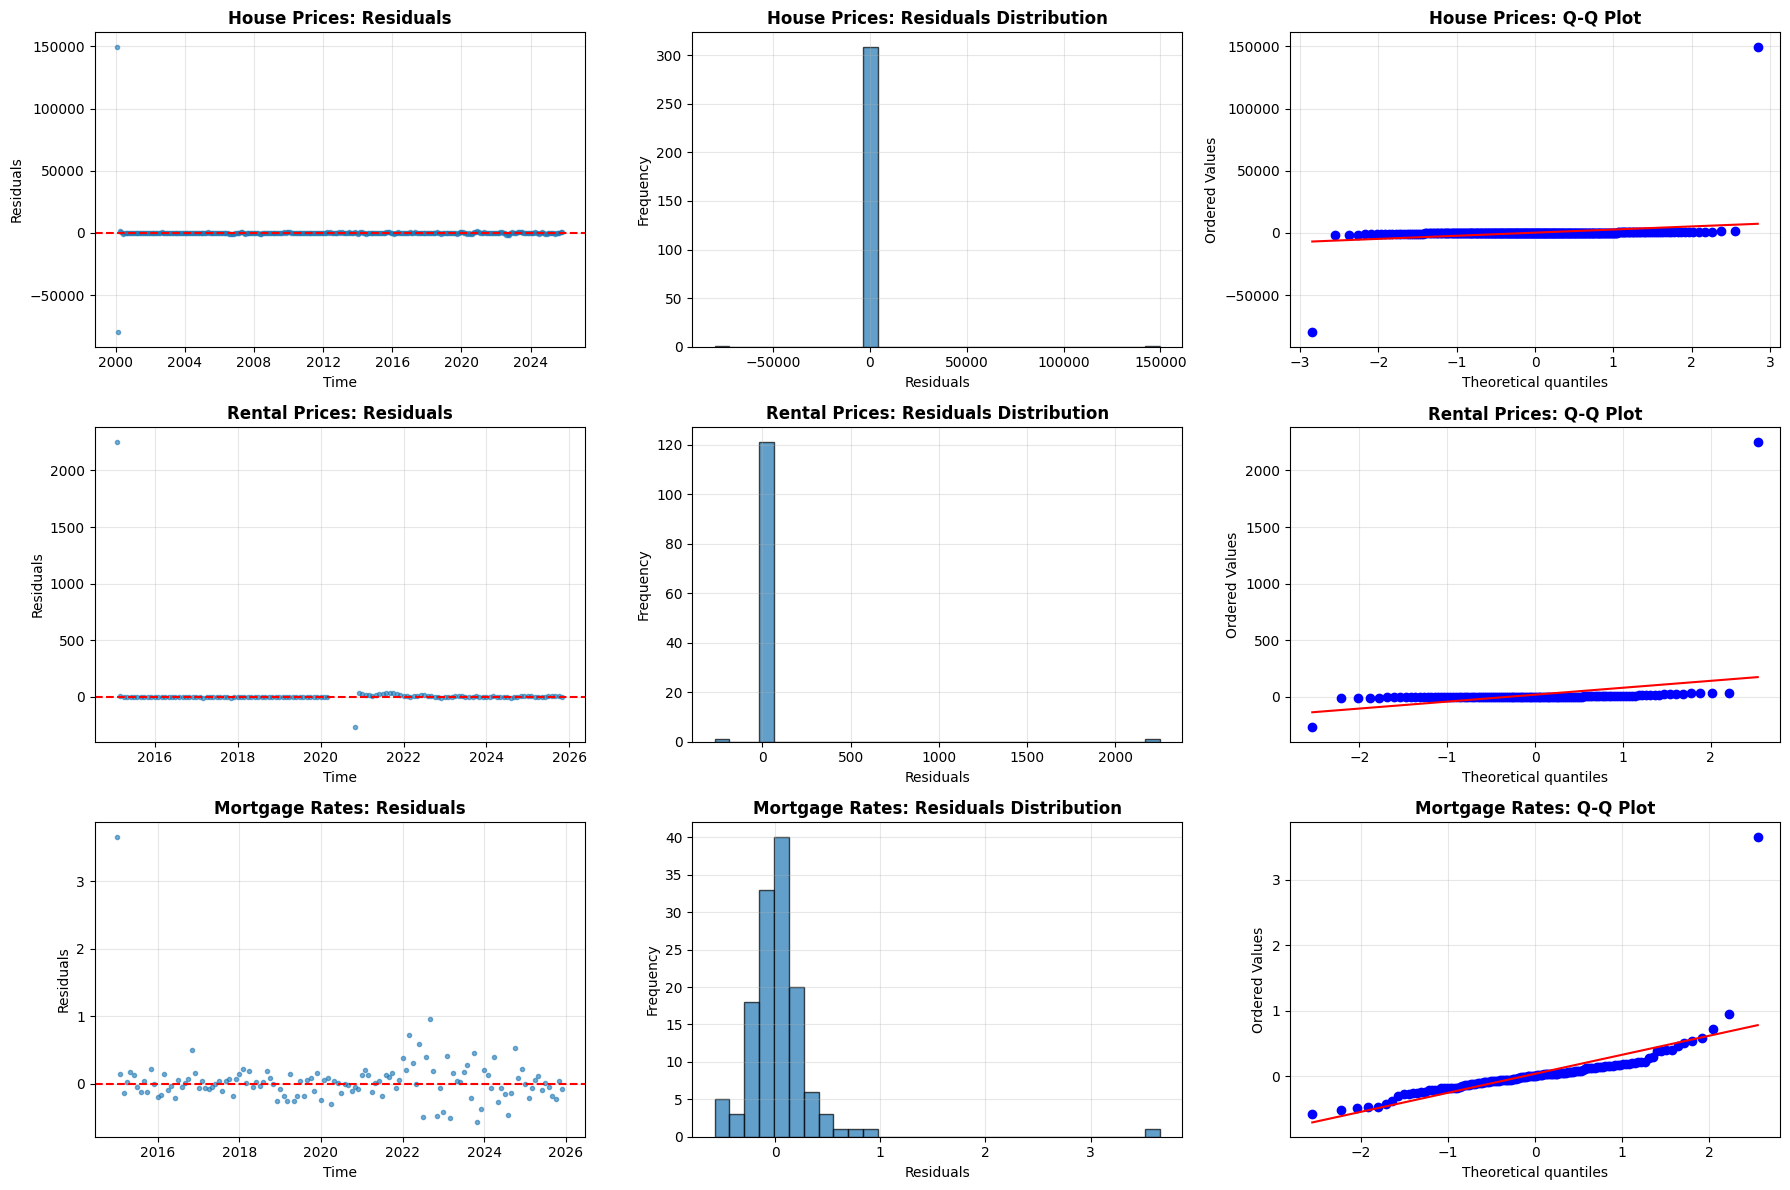

In [85]:
# ============================================
# MODEL DIAGNOSTICS: RESIDUALS ANALYSIS
# ============================================

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# ===== HOUSE PRICES RESIDUALS =====
residuals_house = arima_model_house.resid()

# Residuals plot
axes[0, 0].plot(residuals_house, 'o', markersize=3, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('House Prices: Residuals', fontweight='bold')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

# Residuals histogram
axes[0, 1].hist(residuals_house, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('House Prices: Residuals Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals_house, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('House Prices: Q-Q Plot', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# ===== RENTAL PRICES RESIDUALS =====
residuals_rental = arima_model_rental.resid()

# Residuals plot
axes[1, 0].plot(residuals_rental, 'o', markersize=3, alpha=0.6)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Rental Prices: Residuals', fontweight='bold')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True, alpha=0.3)

# Residuals histogram
axes[1, 1].hist(residuals_rental, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Rental Prices: Residuals Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuals_rental, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Rental Prices: Q-Q Plot', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

# ===== MORTGAGE RATES RESIDUALS =====
residuals_mortgage = arima_model_mortgage.resid()

# Residuals plot
axes[2, 0].plot(residuals_mortgage, 'o', markersize=3, alpha=0.6)
axes[2, 0].axhline(y=0, color='r', linestyle='--')
axes[2, 0].set_title('Mortgage Rates: Residuals', fontweight='bold')
axes[2, 0].set_xlabel('Time')
axes[2, 0].set_ylabel('Residuals')
axes[2, 0].grid(True, alpha=0.3)

# Residuals histogram
axes[2, 1].hist(residuals_mortgage, bins=30, edgecolor='black', alpha=0.7)
axes[2, 1].set_title('Mortgage Rates: Residuals Distribution', fontweight='bold')
axes[2, 1].set_xlabel('Residuals')
axes[2, 1].set_ylabel('Frequency')
axes[2, 1].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuals_mortgage, dist="norm", plot=axes[2, 2])
axes[2, 2].set_title('Mortgage Rates: Q-Q Plot', fontweight='bold')
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [86]:
# ============================================
# MODEL COMPARISON: AIC AND STATISTICS
# ============================================

# Create comparison table
comparison_data = {
    'Model': ['House Prices ARIMA', 'House Prices Prophet',
              'Rental Prices ARIMA', 'Rental Prices Prophet',
              'Mortgage Rates ARIMA', 'Mortgage Rates Prophet'],
    'AIC': [
        arima_model_house.aic(),
        None,  # Prophet doesn't use AIC
        arima_model_rental.aic(),
        None,
        arima_model_mortgage.aic(),
        None
    ],
    'Order': [
        f"{auto_model_house.order} x {auto_model_house.seasonal_order}",
        'Prophet',
        f"{auto_model_rental.order} x {auto_model_rental.seasonal_order}",
        'Prophet',
        f"{auto_model_mortgage.order} x {auto_model_mortgage.seasonal_order}",
        'Prophet'
    ],
    'Residuals_Mean': [
        residuals_house.mean(),
        None,
        residuals_rental.mean(),
        None,
        residuals_mortgage.mean(),
        None
    ],
    'Residuals_Std': [
        residuals_house.std(),
        None,
        residuals_rental.std(),
        None,
        residuals_mortgage.std(),
        None
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Print ARIMA model details
print("\n" + "=" * 80)
print("ARIMA MODEL DETAILS")
print("=" * 80)
print(f"\nHouse Prices:")
print(f"  Model Order: {auto_model_house.order}")
print(f"  Seasonal Order: {auto_model_house.seasonal_order}")
print(f"  AIC: {arima_model_house.aic():.2f}")
print(f"  Residuals Mean: {residuals_house.mean():.4f}")
print(f"  Residuals Std: {residuals_house.std():.4f}")

print(f"\nRental Prices:")
print(f"  Model Order: {auto_model_rental.order}")
print(f"  Seasonal Order: {auto_model_rental.seasonal_order}")
print(f"  AIC: {arima_model_rental.aic():.2f}")
print(f"  Residuals Mean: {residuals_rental.mean():.4f}")
print(f"  Residuals Std: {residuals_rental.std():.4f}")

print(f"\nMortgage Rates:")
print(f"  Model Order: {auto_model_mortgage.order}")
print(f"  Seasonal Order: {auto_model_mortgage.seasonal_order}")
print(f"  AIC: {arima_model_mortgage.aic():.2f}")
print(f"  Residuals Mean: {residuals_mortgage.mean():.4f}")
print(f"  Residuals Std: {residuals_mortgage.std():.4f}")


MODEL COMPARISON SUMMARY
                 Model         AIC                     Order  Residuals_Mean  Residuals_Std
    House Prices ARIMA 4556.009503 (2, 2, 2) x (0, 0, 0, 12)      227.008302    9664.699897
  House Prices Prophet         NaN                   Prophet             NaN            NaN
   Rental Prices ARIMA 1151.099195 (1, 1, 1) x (0, 0, 0, 12)       18.306161     204.999536
 Rental Prices Prophet         NaN                   Prophet             NaN            NaN
  Mortgage Rates ARIMA   -6.671664 (1, 1, 1) x (0, 0, 1, 12)        0.039816       0.390839
Mortgage Rates Prophet         NaN                   Prophet             NaN            NaN

ARIMA MODEL DETAILS

House Prices:
  Model Order: (2, 2, 2)
  Seasonal Order: (0, 0, 0, 12)
  AIC: 4556.01
  Residuals Mean: 227.0083
  Residuals Std: 9664.6999

Rental Prices:
  Model Order: (1, 1, 1)
  Seasonal Order: (0, 0, 0, 12)
  AIC: 1151.10
  Residuals Mean: 18.3062
  Residuals Std: 204.9995

Mortgage Rates:
  Model Orde

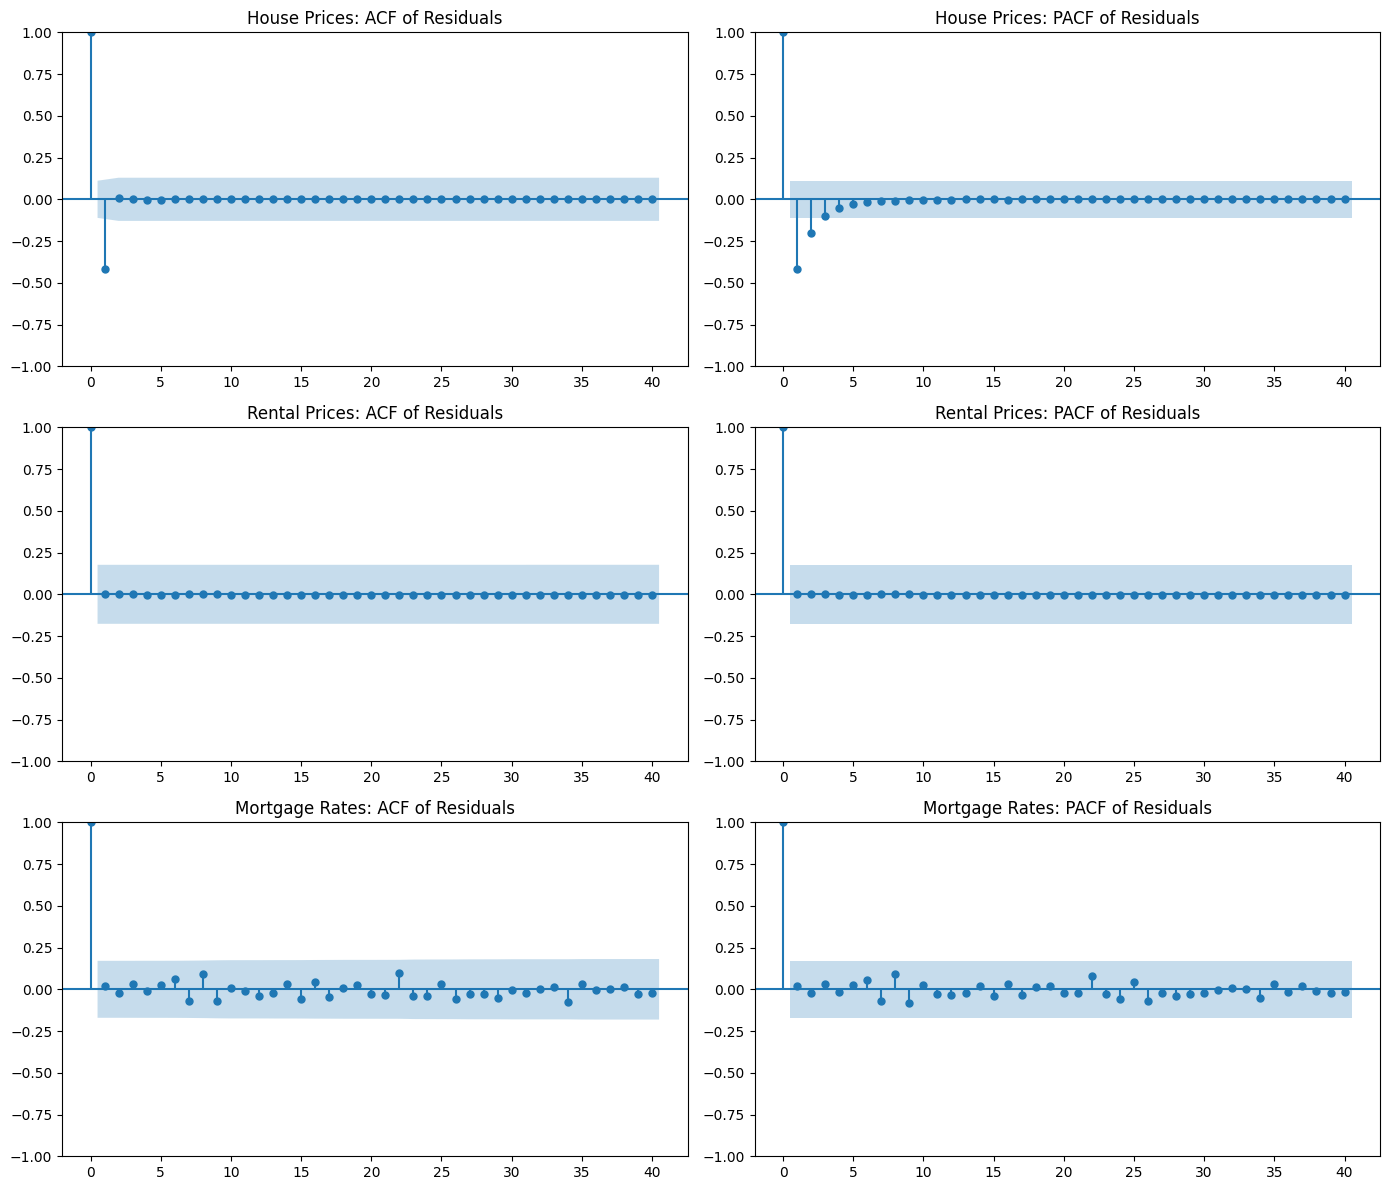

LJUNG-BOX TEST FOR RESIDUAL AUTOCORRELATION

Null Hypothesis: Residuals are independently distributed
(p-value > 0.05 indicates no significant autocorrelation)

House Prices:
  Ljung-Box p-value (lag 10): 0.0000
  ✗ Residuals show autocorrelation

Rental Prices:
  Ljung-Box p-value (lag 10): 1.0000
  ✓ Residuals are independent

Mortgage Rates:
  Ljung-Box p-value (lag 10): 0.9739
  ✓ Residuals are independent


In [87]:
# ============================================
# ACF/PACF PLOTS FOR RESIDUAL DIAGNOSTICS
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# House Prices ACF/PACF
plot_acf(residuals_house, lags=40, ax=axes[0, 0], title='House Prices: ACF of Residuals')
plot_pacf(residuals_house, lags=40, ax=axes[0, 1], title='House Prices: PACF of Residuals')

# Rental Prices ACF/PACF
plot_acf(residuals_rental, lags=40, ax=axes[1, 0], title='Rental Prices: ACF of Residuals')
plot_pacf(residuals_rental, lags=40, ax=axes[1, 1], title='Rental Prices: PACF of Residuals')

# Mortgage Rates ACF/PACF
plot_acf(residuals_mortgage, lags=40, ax=axes[2, 0], title='Mortgage Rates: ACF of Residuals')
plot_pacf(residuals_mortgage, lags=40, ax=axes[2, 1], title='Mortgage Rates: PACF of Residuals')

plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
print("=" * 80)
print("LJUNG-BOX TEST FOR RESIDUAL AUTOCORRELATION")
print("=" * 80)
print("\nNull Hypothesis: Residuals are independently distributed")
print("(p-value > 0.05 indicates no significant autocorrelation)\n")

lb_house = acorr_ljungbox(residuals_house, lags=10, return_df=True)
print("House Prices:")
print(f"  Ljung-Box p-value (lag 10): {lb_house['lb_pvalue'].iloc[-1]:.4f}")
print(f"  {'✓ Residuals are independent' if lb_house['lb_pvalue'].iloc[-1] > 0.05 else '✗ Residuals show autocorrelation'}")

lb_rental = acorr_ljungbox(residuals_rental, lags=10, return_df=True)
print("\nRental Prices:")
print(f"  Ljung-Box p-value (lag 10): {lb_rental['lb_pvalue'].iloc[-1]:.4f}")
print(f"  {'✓ Residuals are independent' if lb_rental['lb_pvalue'].iloc[-1] > 0.05 else '✗ Residuals show autocorrelation'}")

lb_mortgage = acorr_ljungbox(residuals_mortgage, lags=10, return_df=True)
print("\nMortgage Rates:")
print(f"  Ljung-Box p-value (lag 10): {lb_mortgage['lb_pvalue'].iloc[-1]:.4f}")
print(f"  {'✓ Residuals are independent' if lb_mortgage['lb_pvalue'].iloc[-1] > 0.05 else '✗ Residuals show autocorrelation'}")


In [88]:
# ============================================
# FORECAST SUMMARY: ARIMA vs PROPHET
# ============================================

# Create a summary comparison of forecast values
print("=" * 80)
print("FORECAST SUMMARY COMPARISON (10 Years Ahead)")
print("=" * 80)

# House Prices
print("\nHOUSE PRICES:")
print(f"  Historical Last Value: ${house_prices_ts.iloc[-1]:,.2f}")
print(f"  ARIMA Forecast (10 years): ${forecast_arima_house_df['forecast'].iloc[-1]:,.2f}")
print(f"    Change: {((forecast_arima_house_df['forecast'].iloc[-1] / house_prices_ts.iloc[-1]) - 1) * 100:.2f}%")
print(f"  Prophet Forecast (10 years): ${prophet_house_future['yhat'].iloc[-1]:,.2f}")
print(f"    Change: {((prophet_house_future['yhat'].iloc[-1] / house_prices_ts.iloc[-1]) - 1) * 100:.2f}%")

# Rental Prices
print("\nRENTAL PRICES:")
print(f"  Historical Last Value: ${rental_prices_ts.iloc[-1]:,.2f}")
print(f"  ARIMA Forecast (10 years): ${forecast_arima_rental_df['forecast'].iloc[-1]:,.2f}")
print(f"    Change: {((forecast_arima_rental_df['forecast'].iloc[-1] / rental_prices_ts.iloc[-1]) - 1) * 100:.2f}%")
print(f"  Prophet Forecast (10 years): ${prophet_rental_future['yhat'].iloc[-1]:,.2f}")
print(f"    Change: {((prophet_rental_future['yhat'].iloc[-1] / rental_prices_ts.iloc[-1]) - 1) * 100:.2f}%")

# Mortgage Rates
print("\nMORTGAGE RATES:")
print(f"  Historical Last Value: {mortgage_rates_ts.iloc[-1]:.2f}%")
print(f"  ARIMA Forecast (10 years): {forecast_arima_mortgage_df['forecast'].iloc[-1]:.2f}%")
print(f"    Change: {forecast_arima_mortgage_df['forecast'].iloc[-1] - mortgage_rates_ts.iloc[-1]:.2f} percentage points")
print(f"  Prophet Forecast (10 years): {prophet_mortgage_future['yhat'].iloc[-1]:.2f}%")
print(f"    Change: {prophet_mortgage_future['yhat'].iloc[-1] - mortgage_rates_ts.iloc[-1]:.2f} percentage points")

print("\n" + "=" * 80)
print("ARIMA/SARIMA FORECASTING COMPLETE")
print("=" * 80)


FORECAST SUMMARY COMPARISON (10 Years Ahead)

HOUSE PRICES:
  Historical Last Value: $505,959.52
  ARIMA Forecast (10 years): $751,446.06
    Change: 48.52%
  Prophet Forecast (10 years): $813,779.84
    Change: 60.84%

RENTAL PRICES:
  Historical Last Value: $3,372.41
  ARIMA Forecast (10 years): $4,490.33
    Change: 33.15%
  Prophet Forecast (10 years): $4,661.39
    Change: 38.22%

MORTGAGE RATES:
  Historical Last Value: 6.22%
  ARIMA Forecast (10 years): 6.00%
    Change: -0.22 percentage points
  Prophet Forecast (10 years): 14.55%
    Change: 8.33 percentage points

ARIMA/SARIMA FORECASTING COMPLETE


Buy vs Rent recommendation (next 10 years, $250k principal):
  Prophet-based outlook: Buy (avg buy cost $-56 vs rent $4,009)
  ARIMA-based outlook:   Buy (avg buy cost $-525 vs rent $3,942)


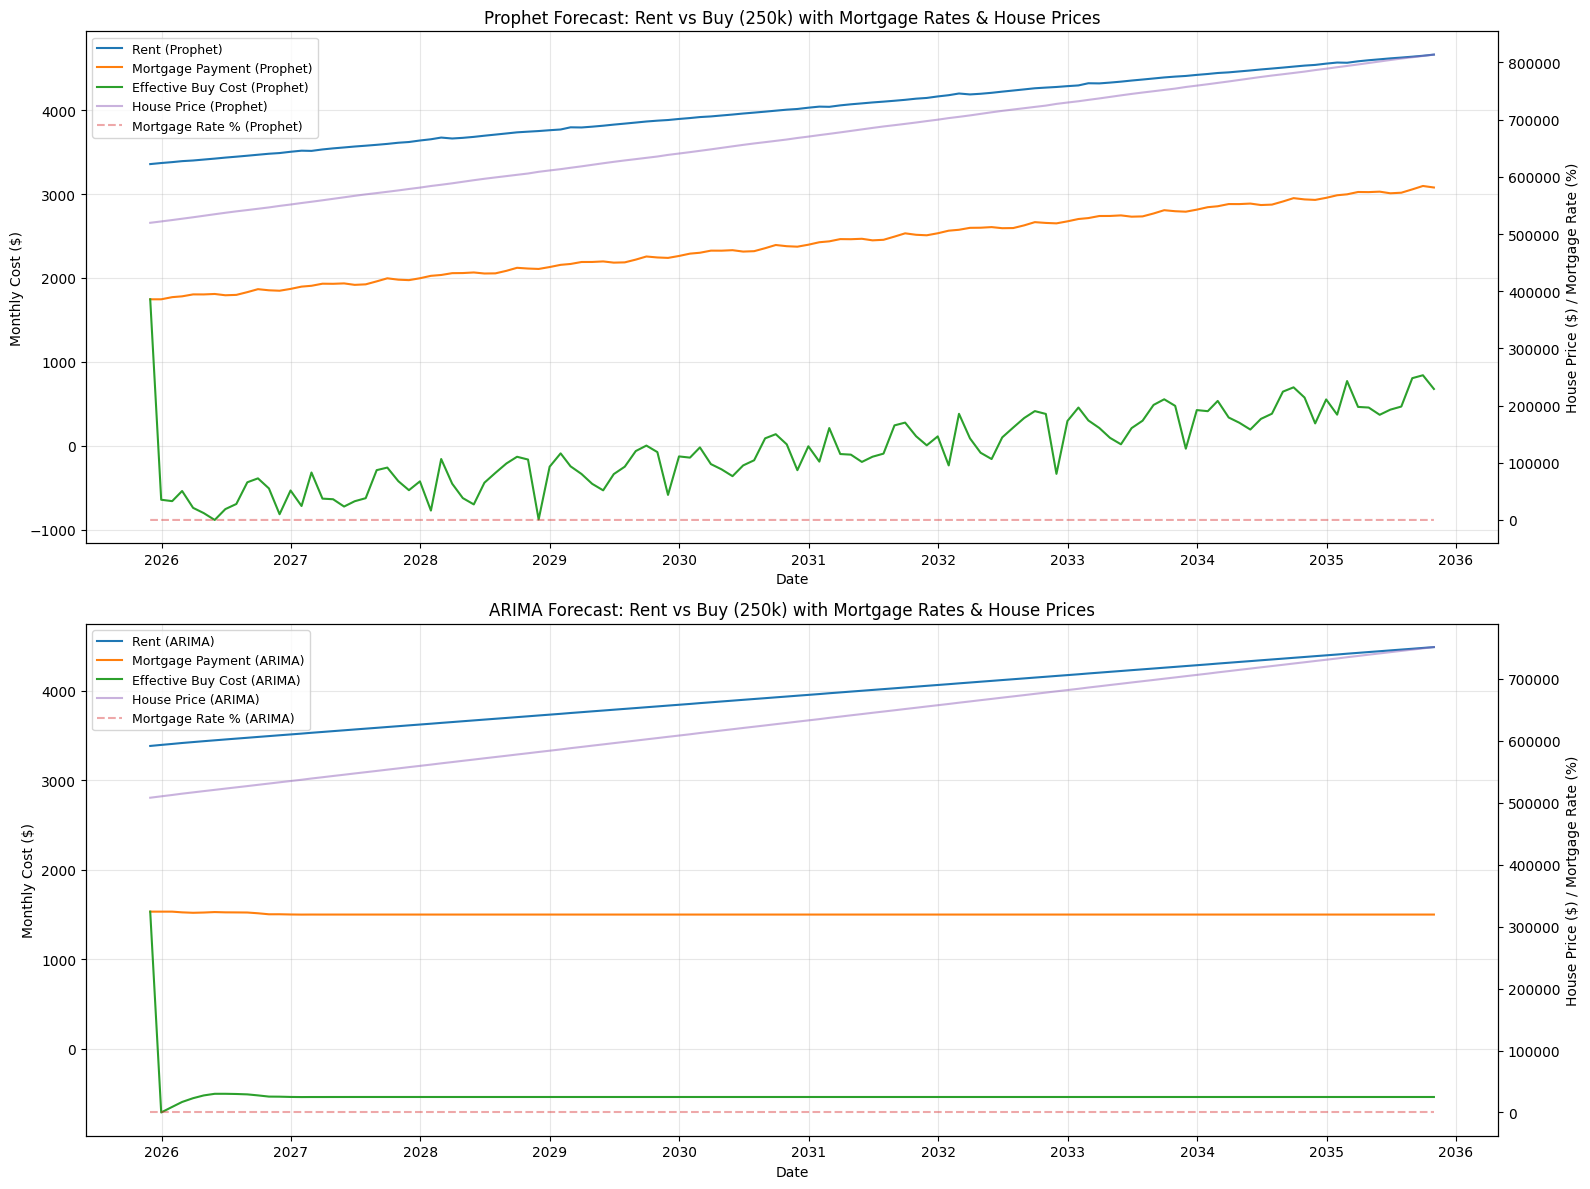

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure required Prophet forecast slices exist (in case this cell is run standalone)
if 'prophet_house_future' not in globals():
    # build future-only slice from existing forecast_house and house_prices_prophet
    last_hist_house = house_prices_prophet['ds'].max()
    prophet_house_future = forecast_house[forecast_house['ds'] > last_hist_house]
if 'prophet_rental_future' not in globals():
    last_hist_rent = rental_prices_prophet['ds'].max()
    prophet_rental_future = forecast_rental[forecast_rental['ds'] > last_hist_rent]
if 'prophet_mortgage_future' not in globals():
    last_hist_mtg = mortgage_prophet['ds'].max()
    prophet_mortgage_future = forecast_mortgage[forecast_mortgage['ds'] > last_hist_mtg]

# Ensure ARIMA forecast frames exist (they should be created earlier)
if 'forecast_arima_house_df' not in globals() or 'forecast_arima_rental_df' not in globals() or 'forecast_arima_mortgage_df' not in globals():
    raise RuntimeError("Run the ARIMA forecast cells before this buy-vs-rent analysis.")

# ============================================
# BUY VS RENT DECISION (250K BUDGET) USING PROPHET & ARIMA
# ============================================

# Assumptions:
# - Budget / loan principal: $250,000
# - 30-year fixed loan term
# - Monthly mortgage payment computed from forecasted mortgage rates
# - "Effective buy cost" = monthly mortgage payment minus expected monthly appreciation
#   (appreciation offsets the cost of ownership); if appreciation is negative it does not offset.

investment_amount = 250_000
loan_term_years = 30
months_in_year = 12


def monthly_payment(principal: float, annual_rate_pct):
    """Compute monthly payment for a fixed-rate mortgage (supports scalar/Series)."""
    annual_rate = pd.Series(annual_rate_pct)  # ensure vectorized math
    monthly_rate = annual_rate / 100 / months_in_year
    n_payments = loan_term_years * months_in_year
    # Avoid division by zero if rate is ~0
    with np.errstate(divide='ignore', invalid='ignore'):
        payment = principal * (monthly_rate * (1 + monthly_rate) ** n_payments) / ((1 + monthly_rate) ** n_payments - 1)
    payment = payment.fillna(principal / n_payments)  # fallback for ~0% rate
    return payment


# ---------- Prophet-based scenario ----------
# Handle cases where forecast frames keep datetime in index instead of 'ds' column
prophet_house_future = prophet_house_future.copy()
prophet_rental_future = prophet_rental_future.copy()
prophet_mortgage_future = prophet_mortgage_future.copy()

if 'ds' not in prophet_house_future.columns:
    prophet_house_future = prophet_house_future.rename_axis('ds').reset_index()
if 'ds' not in prophet_rental_future.columns:
    prophet_rental_future = prophet_rental_future.rename_axis('ds').reset_index()
if 'ds' not in prophet_mortgage_future.columns:
    prophet_mortgage_future = prophet_mortgage_future.rename_axis('ds').reset_index()

prophet_index = pd.to_datetime(prophet_house_future['ds'])
prophet_join = pd.DataFrame(index=prophet_index)
prophet_join['house_price'] = prophet_house_future['yhat'].values
prophet_join['rent'] = prophet_rental_future.set_index('ds')['yhat'].reindex(prophet_index).interpolate().ffill().bfill()
prophet_join['mortgage_rate'] = prophet_mortgage_future.set_index('ds')['yhat'].reindex(prophet_index).interpolate().ffill().bfill().clip(lower=0)
prophet_join['mortgage_payment'] = monthly_payment(investment_amount, prophet_join['mortgage_rate'])
prophet_join['monthly_appreciation'] = prophet_join['house_price'].diff().fillna(0)
prophet_join['effective_buy_cost'] = prophet_join['mortgage_payment'] - prophet_join['monthly_appreciation'].clip(lower=0)
prophet_join['decision'] = np.where(prophet_join['effective_buy_cost'] <= prophet_join['rent'], 'Buy', 'Rent')
prophet_choice = prophet_join['decision'].mode().iloc[0]

# ---------- ARIMA-based scenario ----------
arima_index = pd.to_datetime(forecast_arima_house_df.index)
arima_join = pd.DataFrame(index=arima_index)
arima_join['house_price'] = forecast_arima_house_df['forecast'].values
arima_join['rent'] = forecast_arima_rental_df['forecast'].reindex(arima_index).interpolate().ffill().bfill()
arima_join['mortgage_rate'] = forecast_arima_mortgage_df['forecast'].reindex(arima_index).interpolate().ffill().bfill().clip(lower=0)
arima_join['mortgage_payment'] = monthly_payment(investment_amount, arima_join['mortgage_rate'])
arima_join['monthly_appreciation'] = arima_join['house_price'].diff().fillna(0)
arima_join['effective_buy_cost'] = arima_join['mortgage_payment'] - arima_join['monthly_appreciation'].clip(lower=0)
arima_join['decision'] = np.where(arima_join['effective_buy_cost'] <= arima_join['rent'], 'Buy', 'Rent')
arima_choice = arima_join['decision'].mode().iloc[0]

print("Buy vs Rent recommendation (next 10 years, $250k principal):")
print(f"  Prophet-based outlook: {prophet_choice} (avg buy cost ${prophet_join['effective_buy_cost'].mean():,.0f} vs rent ${prophet_join['rent'].mean():,.0f})")
print(f"  ARIMA-based outlook:   {arima_choice} (avg buy cost ${arima_join['effective_buy_cost'].mean():,.0f} vs rent ${arima_join['rent'].mean():,.0f})")

# ---------- Visualizations ----------
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Prophet plot
ax = axes[0]
ax.plot(prophet_join.index, prophet_join['rent'], label='Rent (Prophet)', color='tab:blue')
ax.plot(prophet_join.index, prophet_join['mortgage_payment'], label='Mortgage Payment (Prophet)', color='tab:orange')
ax.plot(prophet_join.index, prophet_join['effective_buy_cost'], label='Effective Buy Cost (Prophet)', color='tab:green')
ax2 = ax.twinx()
ax2.plot(prophet_join.index, prophet_join['house_price'], label='House Price (Prophet)', color='tab:purple', alpha=0.5)
ax2.plot(prophet_join.index, prophet_join['mortgage_rate'], label='Mortgage Rate % (Prophet)', color='tab:red', alpha=0.4, linestyle='--')
ax.set_title('Prophet Forecast: Rent vs Buy (250k) with Mortgage Rates & House Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Cost ($)')
ax2.set_ylabel('House Price ($) / Mortgage Rate (%)')
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# ARIMA plot
ax = axes[1]
ax.plot(arima_join.index, arima_join['rent'], label='Rent (ARIMA)', color='tab:blue')
ax.plot(arima_join.index, arima_join['mortgage_payment'], label='Mortgage Payment (ARIMA)', color='tab:orange')
ax.plot(arima_join.index, arima_join['effective_buy_cost'], label='Effective Buy Cost (ARIMA)', color='tab:green')
ax2 = ax.twinx()
ax2.plot(arima_join.index, arima_join['house_price'], label='House Price (ARIMA)', color='tab:purple', alpha=0.5)
ax2.plot(arima_join.index, arima_join['mortgage_rate'], label='Mortgage Rate % (ARIMA)', color='tab:red', alpha=0.4, linestyle='--')
ax.set_title('ARIMA Forecast: Rent vs Buy (250k) with Mortgage Rates & House Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Cost ($)')
ax2.set_ylabel('House Price ($) / Mortgage Rate (%)')
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
# ============================================
# WEALTH PROJECTION (30 YEARS): BUY VS RENT
# ============================================

# Requirements: Prophet and ARIMA models already fitted above; monthly_payment defined.
if 'model_house' not in globals() or 'model_rental' not in globals() or 'model_mortgage' not in globals():
    raise RuntimeError("Run the Prophet training cells before this wealth projection.")

# Forecast 30 years (360 months) ahead with Prophet
horizon_months = 360

house_future_30 = model_house.make_future_dataframe(periods=horizon_months, freq='M')
rent_future_30 = model_rental.make_future_dataframe(periods=horizon_months, freq='M')
mortgage_future_30 = model_mortgage.make_future_dataframe(periods=horizon_months, freq='M')

forecast_house_30 = model_house.predict(house_future_30)
forecast_rent_30 = model_rental.predict(rent_future_30)
forecast_mortgage_30 = model_mortgage.predict(mortgage_future_30)

# Keep only future horizon beyond historical
last_hist_house = house_prices_prophet['ds'].max()
last_hist_rent = rental_prices_prophet['ds'].max()
last_hist_mtg = mortgage_prophet['ds'].max()

forecast_house_30 = forecast_house_30[forecast_house_30['ds'] > last_hist_house].head(horizon_months)
forecast_rent_30 = forecast_rent_30[forecast_rent_30['ds'] > last_hist_rent].head(horizon_months)
forecast_mortgage_30 = forecast_mortgage_30[forecast_mortgage_30['ds'] > last_hist_mtg].head(horizon_months)

# Align dates
proj_index = pd.to_datetime(forecast_house_30['ds'])
rent_series = forecast_rent_30.set_index('ds')['yhat'].reindex(proj_index).interpolate().ffill().bfill()
mortgage_rate_series = forecast_mortgage_30.set_index('ds')['yhat'].reindex(proj_index).interpolate().ffill().bfill().clip(lower=0)

# Assumptions
principal = investment_amount  # 250k
annual_return_invest = 0.05
monthly_return = annual_return_invest / 12
initial_house_price = house_prices_ts.iloc[-1]

# Fixed-rate mortgage using first forecasted rate
fixed_rate = float(mortgage_rate_series.iloc[0])
monthly_pay = monthly_payment(principal, fixed_rate).iloc[0]

balance = principal
balances = []
buy_equity = []
rent_wealth = []
invest_balance = 0.0

house_price_path = forecast_house_30['yhat'].values
rent_path = rent_series.values

for i, dt in enumerate(proj_index):
    # Mortgage amortization
    interest = balance * (fixed_rate / 100) / 12
    principal_paid = max(monthly_pay - interest, 0)
    balance = max(balance - principal_paid, 0)
    balances.append(balance)

    # House equity (value minus remaining balance)
    house_val = house_price_path[i]
    equity = max(house_val - balance, 0)
    buy_equity.append(equity)

    # Renting: invest the difference if mortgage payment > rent; if rent higher, invest 0
    surplus = max(monthly_pay - rent_path[i], 0)
    invest_balance = invest_balance * (1 + monthly_return) + surplus
    rent_wealth.append(invest_balance)

wealth_df = pd.DataFrame({
    'Date': proj_index,
    'House_Value': house_price_path,
    'Mortgage_Balance': balances,
    'Home_Equity_Buy': buy_equity,
    'Rent_Payment': rent_path,
    'Rent_Wealth': rent_wealth,
    'Fixed_Mortgage_Payment': monthly_pay,
    'Fixed_Rate_%': fixed_rate
}).set_index('Date')

print("30-year wealth projection (Prophet-based):")
print(f"  Fixed mortgage rate used: {fixed_rate:.2f}% | Monthly payment: ${monthly_pay:,.0f}")
print(f"  Ending home equity: ${wealth_df['Home_Equity_Buy'].iloc[-1]:,.0f}")
print(f"  Ending renter invested balance: ${wealth_df['Rent_Wealth'].iloc[-1]:,.0f}")

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(wealth_df.index, wealth_df['Home_Equity_Buy'], label='Home Equity (Buy)', color='tab:green')
ax.plot(wealth_df.index, wealth_df['Rent_Wealth'], label='Investment Balance (Rent)', color='tab:blue')
ax.set_title('Wealth Projection Over 30 Years: Buy vs Rent (Prophet-based)')
ax.set_xlabel('Date')
ax.set_ylabel('Wealth ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

